# 05 · Does clustering add anything over RFM?
Variables (behaviour only, no pilot outcome): recency, log(frequency), log(spend), web visits (capped at p99.5), deal share,
catalog share, wine share, prior campaign acceptance rate. Standardised; correlations inspected; K chosen by a rule declared
before looking at segment content: **mean bootstrap ARI ≥ 0.8, no cluster < 5 %, then highest silhouette**.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4g}")
from src import pipeline as P
from src.config import *

In [2]:
ctx = P.prepare('stage_segmentation')
from src.segmentation import cluster_matrix
X = cluster_matrix(ctx['feat'])
print('skew of raw spend:', round(ctx['feat'].total_spend.skew(), 2), '| after log1p:', round(X.log_monetary.skew(), 2))
X.describe().T[['mean','std','min','max']]

skew of raw spend: 0.86 | after log1p: -0.38


,mean,std,min,max
Recency,49.26,28.94,0,99
log_frequency,2.437,0.6143,0,3.497
log_monetary,5.62,1.474,1.792,7.834
NumWebVisitsMonth,5.268,2.315,0,10
deals_share,0.2399,0.1722,0,1
share_catalog,0.1639,0.1412,0,1
share_wines,0.4584,0.2291,0,0.9633
prior_accept_rate,0.05963,0.136,0,0.8


In [3]:
X.corr().round(2)

,Recency,log_frequency,log_monetary,NumWebVisitsMonth,deals_share,share_catalog,share_wines,prior_accept_rate
Recency,1,0.01,0.02,-0.01,0.01,0.03,-0.01,-0.02
log_frequency,0.01,1,0.94,-0.41,-0.52,0.6,0.28,0.29
log_monetary,0.02,0.94,1,-0.46,-0.58,0.67,0.27,0.35
NumWebVisitsMonth,-0.01,-0.41,-0.46,1,0.55,-0.52,0.03,-0.17
deals_share,0.01,-0.52,-0.58,0.55,1,-0.41,-0.09,-0.28
share_catalog,0.03,0.6,0.67,-0.52,-0.41,1,0.04,0.31
share_wines,-0.01,0.28,0.27,0.03,-0.09,0.04,1,0.19
prior_accept_rate,-0.02,0.29,0.35,-0.17,-0.28,0.31,0.19,1


[19:40:56] segmentation


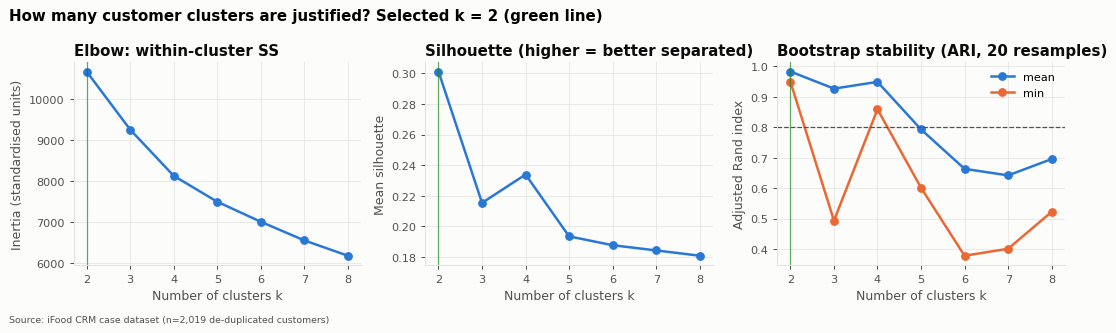

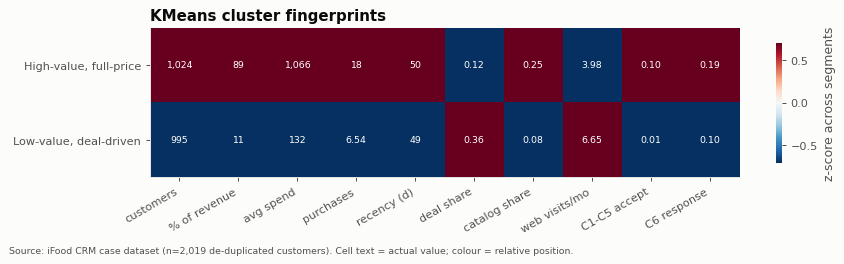

,k,inertia,silhouette,stability_ari_mean,stability_ari_min,min_cluster_share
0,2,1.067e+04,0.3013,0.9827,0.9491,0.4928
1,3,"9,251",0.2153,0.9265,0.4931,0.3006
2,4,"8,121",0.2338,0.9487,0.8588,0.05993
3,5,"7,488",0.1934,0.7926,0.6011,0.05993
4,6,"6,999",0.1876,0.6632,0.3781,0.06043
5,7,"6,544",0.1842,0.6417,0.4008,0.05993
6,8,"6,169",0.1807,0.6953,0.5221,0.05993


In [4]:
ctx = P.stage_segmentation(ctx)
ctx['k_eval']

In [5]:
ctx['cluster_profiles']

,customers,share_customers_pct,total_spend,share_revenue_pct,avg_spend,median_spend,avg_purchases,avg_recency_days,avg_aov,avg_web_visits,deals_share,catalog_share,prior5_accept_rate,pilot_response_rate,avg_income,avg_children
cluster_label,,,,,,,,,,,,,,,,
"High-value, full-price",1024,50.72,1091623,89.26,"1,066","1,028",18.35,49.6,59.68,3.985,0.122,0.249,0.103,0.192,6.799e+04,0.61
"Low-value, deal-driven",995,49.28,131387,10.74,132,68,6.541,48.91,16.32,6.654,0.364,0.077,0.015,0.097,3.563e+04,1.299


In [6]:
ctx['seg_compare']

,segmentation,n_segments,response_cramers_v,response_rate_range,spend_eta_squared
0,rfm_segment,9,0.2672,0.2978,0.7225
1,cluster_label,2,0.1345,0.0949,0.6032


In [7]:
import pandas as pd
pd.read_csv(TAB/'cluster_vs_rfm_crosstab.csv')

,cluster_label,Core high-value (recent),High-value (cooling),High-value (lapsing),Low-value (cooling),Low-value (lapsing),Low-value (recent),Mid-value (cooling),Mid-value (lapsing),Mid-value (recent)
0,"High-value, full-price",224,215,221,2,6,0,118,121,117
1,"Low-value, deal-driven",4,5,4,226,216,223,107,105,105


> **Finding:** The selected solution has k = 2 (silhouette 0.30, bootstrap ARI 0.98): a high-value full-price group and a low-value deal-driven group. It separates pilot response less than the 9 RFM segments (Cramér's V 0.135 vs 0.267) and explains less spend variance (η² 0.60 vs 0.72). Solutions with k ≥ 5 are unstable (ARI < 0.8).
>
> **Business implication:** KMeans adds little beyond RFM here — its main split is 'spend level', which RFM already captures.
>
> **Recommended action:** Keep RFM as the segmentation of record; report the cluster only as a descriptive attribute (deal-driven vs full-price).
>
> **Evidence:** k-selection table, stability ARI, RFM-vs-KMeans comparison.
>
> **Assumption:** Euclidean distance on standardised features is a meaningful similarity.
>
> **Limitation:** k = 4 is also stable (ARI 0.95) and isolates a small campaign-responsive cluster — but only because prior acceptance is an input; this is recorded as a SENSITIVE finding in notebook 11.